In [10]:
import numpy as np
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix
import scipy.sparse

In [11]:
def read_custom_file(file_path, top_peak_num):
    data = {
        "mzs": [],
        "coordinates": [],
        "intensities": [],
        "sample_numbers": [],
        "row_numbers": []
    }
    x_coordinates = []
    y_coordinates = []

    with open(file_path, 'r') as file:
        # Skip the first line
        file.readline()
        file.readline()

        # Read the second row (number of columns)
        column_count = (file.readline().strip())

        # Read the third row (m/z values) and round them
        #mz_row = list(map(lambda x: round(float(x), 2), file.readline().strip().split()))
        mz_row = list(map(float, file.readline().strip().split()))
        data["mzs"] = mz_row
        i = 0
        # Read the remaining rows for coordinates and intensities
        for line in file:
            values = line.strip().split()
                
            # Ensure there are at least 10 columns to process
            if len(values) >= 1005:
                row_number = int(values[0].strip())  # Row number (1st column)
                x_coordinate = float(values[1].strip())  # X coordinate (2nd column)
                y_coordinate = float(values[2].strip())  # Y coordinate (3rd column)

                # Collect x and y coordinates to calculate minimums later
                x_coordinates.append(x_coordinate)
                y_coordinates.append(y_coordinate)

                
                # Extract mz intensities (4th to 8th columns)
                mz_intensities = list(map(float, [val.strip() for val in values[3:top_peak_num+3]]))
                sample_number = int(values[top_peak_num+3].strip())  # Sample number (9th column)
                row_number_again = int(values[top_peak_num+4].strip())  # Row number again (10th column)

                # Append the extracted values to the data dictionary
                data["intensities"].append(mz_intensities)
                data["sample_numbers"].append(sample_number)
                data["row_numbers"].append(row_number_again)
                
    # Find the minimum x and y coordinates
    min_x = min(x_coordinates)
    min_y = min(y_coordinates)
    #data["coordinates"].append((x_coordinate, y_coordinate))
    # Adjust all coordinates to start from zero
    data["coordinates"] = [(x - min_x, y - min_y) for x, y in zip(x_coordinates, y_coordinates)]
                
    return data

In [12]:
def create_csr_matrix(data):
    # Extract m/z values and their corresponding intensities
    mzs = data["mzs"]
    intensities = data["intensities"]  # A list of lists or 2D array-like (intensity values per row)
    coordinates = data["coordinates"]
    
    # Lists to store the sparse matrix indices and values
    rows = []
    cols = []
    values = []

    # Build the sparse matrix by iterating over the data
    for i, intensity_row in enumerate(intensities):
        for j, intensity in enumerate(intensity_row):
            if intensity != 0:  # Add only non-zero values
                rows.append(i)
                cols.append(j)
                values.append(intensity)

    # Create the sparse matrix in CSR format
    X_sparse = csr_matrix((values, (rows, cols)), shape=(len(intensities), len(mzs)))

    return X_sparse, mzs, np.array(coordinates)

In [13]:

def setup_spatial_data(adata, image_size_cm, image_resolution):
    
    # Create a blank image with the specified resolution
    img_size_px = int(image_size_cm / image_resolution)  # Convert cm to pixels
    blank_image = np.zeros((img_size_px, img_size_px, 3), dtype=np.uint8)  # Create a blank RGB image

    # Set up the spatial dictionary with the blank image and coordinates
    adata.uns['spatial'] = {
        'spatial': {
            'scalefactors': {
                'tissue_hires_scalef': 1.0,
                'spot_diameter_fullres': 0.05  # Arbitrary spot diameter in pixels, adjust as needed
            },
            'images': {
                'hires': blank_image,  # Set blank image for visualization
                'lowres': blank_image  # Low-resolution image (same as blank)
            }
        }
    }

    # Example: Ensure adata.obs contains the x and y coordinates of the spots
    if 'x' not in adata.obs or 'y' not in adata.obs:
        raise ValueError("adata.obs must contain 'x' and 'y' coordinates.")

    print("Spatial data setup complete.")
    return adata


In [14]:
def normalize_based_on_tic(adata):
    # Calculate TIC if not already present
    adata.obs['TIC'] = np.sum(adata.X.toarray(), axis=1)

    # Normalize intensities by TIC for each spot
    tic_values = adata.obs['TIC'].values
    normalized_matrix = adata.X.toarray() / tic_values[:, np.newaxis]

    # Store the normalized matrix as a separate layer
    adata.layers['tic_normalized'] = scipy.sparse.csr_matrix(normalized_matrix)
    # Replace the original adata.X with the normalized matrix (in sparse format)
    #adata.X = scipy.sparse.csr_matrix(normalized_matrix)

    return adata

In [15]:
def metadata(adata, sample_num, batch_num, age_group, disease_status ):
    metadata = {
        'sample': [sample_num] * len(adata.obs),  # Change according to each sample's number
        'batch': [batch_num] * len(adata.obs),  # Change according to each sample's slide number
        'age_group': [age_group] * len(adata.obs),  # Young or Aged
        'disease_status': [disease_status] * len(adata.obs),  # Control or AD
    }
    
    # Convert the metadata dictionary to a DataFrame
    metadata_df = pd.DataFrame(metadata, index=adata.obs.index)
    
    # Add the metadata to `adata.obs`
    adata.obs = adata.obs.join(metadata_df)
    return adata

In [16]:
def ann_data_creator(file_path,top_peak_num,image_size_cm, image_resolution,sample_num, batch_num, age_group, disease_status):  
    file_data = read_custom_file(file_path, top_peak_num)
    sparse_matrix, mzs, coordinates = create_csr_matrix(file_data)
    adata = sc.AnnData(X=sparse_matrix, obs={"x": coordinates[:, 0], "y": coordinates[:, 1]})
    mzs_df = pd.DataFrame(index=mzs)
    adata.var= mzs_df
    adata.var['mzs'] = mzs
    adata.obsm['spatial']= coordinates
    adata = setup_spatial_data(adata, image_size_cm, image_resolution)
    adata = normalize_based_on_tic(adata)
    adata = metadata(adata, sample_num ,batch_num, age_group, disease_status )
    adata.raw = adata.copy()
    return adata

In [17]:
adata = ann_data_creator(file_path = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/20230918_3xTgAD_oldfemale_1_pos_3_10000.txt",
                         top_peak_num = 10000,
                         image_size_cm=20, 
                         image_resolution=0.001,
                         sample_num = '4-3',
                         batch_num = 'Slide_4', 
                         age_group = 'Aged',
                         disease_status = 'AD'
                        )


/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:750: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    [273.0411, 137.0243, 274.0449, 331.0315, 369.3527]

    Inferred to be: floating

  value_idx = self._prep_dim_index(value.index, attr)


Spatial data setup complete.


/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [18]:
print(f"{adata}: Matrix shape = {adata.X.shape}, Non-zero elements = {adata.X.nnz if hasattr(adata.X, 'nnz') else 'N/A'}")

AnnData object with n_obs × n_vars = 16605 × 10000
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status'
    var: 'mzs'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'tic_normalized': Matrix shape = (16605, 10000), Non-zero elements = 80653440


In [19]:
adata.var


,mzs
273.0411,273.0411
137.0243,137.0243
274.0449,274.0449
331.0315,331.0315
369.3527,369.3527
...,...
300.4875,300.4875
409.8351,409.8351
310.8359,310.8359
76.0224,76.0224


In [20]:
adata.obs

,x,y,TIC,sample,batch,age_group,disease_status
0,0.00,0.00,473597.0,4-3,Slide_4,Aged,AD
1,0.06,0.00,406117.0,4-3,Slide_4,Aged,AD
2,0.12,0.00,690045.0,4-3,Slide_4,Aged,AD
3,0.18,0.00,607887.0,4-3,Slide_4,Aged,AD
4,0.24,0.00,368125.0,4-3,Slide_4,Aged,AD
...,...,...,...,...,...,...,...
16600,7.80,7.32,1351268.0,4-3,Slide_4,Aged,AD
16601,7.86,7.32,1390803.0,4-3,Slide_4,Aged,AD
16602,7.92,7.32,1968182.0,4-3,Slide_4,Aged,AD
16603,7.98,7.32,1425836.0,4-3,Slide_4,Aged,AD


In [21]:
adata.X

<16605x10000 sparse matrix of type '<class 'numpy.float64'>'
	with 80653440 stored elements in Compressed Sparse Row format>

In [22]:
adata.write('20230918_3xTgAD_oldfemale_1_pos_3_10000.h5ad')

In [49]:
adata

AnnData object with n_obs × n_vars = 17958 × 1000
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status'
    var: 'mzs'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'tic_normalized'

In [56]:
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)
adata

AnnData object with n_obs × n_vars = 18495 × 1000
    obs: 'x', 'y', 'TIC', 'sample', 'batch', 'age_group', 'disease_status', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'mzs', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'tic_normalized'

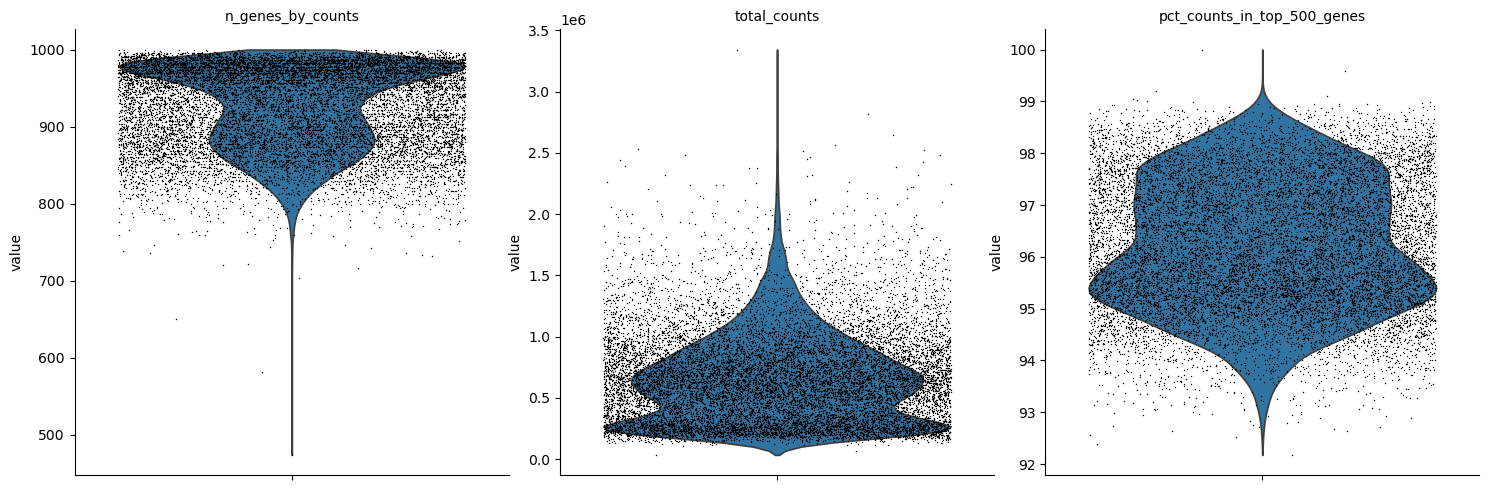

In [70]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", 'pct_counts_in_top_500_genes'],
    jitter=0.4,
    multi_panel=True,
)

In [71]:

# Convert the sparse matrix to CSC format for efficient column operations
sparse_matrix = adata.X.tocsc()

# Count the number of non-zero entries in each column (m/z feature)
non_zero_counts = (sparse_matrix != 0).sum(axis=0)

# Flatten the result to get a 1D array
non_zero_counts = np.array(non_zero_counts).flatten()

# Find the indices of the top m/z features with the highest non-zero counts
top_mzs_indices = np.argsort(non_zero_counts)[-60:]

# Extract the actual m/z values using the correct indices
top_mzs = adata.var.index[top_mzs_indices]

# Print the top m/z values and their non-zero counts
for i in top_mzs_indices:
    print(f"m/z: {adata.var.index[i]}, Non-zero count: {non_zero_counts[i]}")

m/z: 409.0547, Non-zero count: 15195
m/z: 366.9644, Non-zero count: 15195
m/z: 313.0307, Non-zero count: 15195
m/z: 350.9893, Non-zero count: 15195
m/z: 763.5991, Non-zero count: 15195
m/z: 317.1016, Non-zero count: 15195
m/z: 330.0219, Non-zero count: 15195
m/z: 247.0586, Non-zero count: 15195
m/z: 184.0733, Non-zero count: 15195
m/z: 333.1225, Non-zero count: 15195
m/z: 784.573, Non-zero count: 15195
m/z: 181.0841, Non-zero count: 15195
m/z: 213.0546, Non-zero count: 15195
m/z: 332.0917, Non-zero count: 15195
m/z: 501.0335, Non-zero count: 15195
m/z: 272.0308, Non-zero count: 15195
m/z: 760.5824, Non-zero count: 15196
m/z: 331.0304, Non-zero count: 15196
m/z: 245.044, Non-zero count: 15196
m/z: 257.0441, Non-zero count: 15196
m/z: 734.5667, Non-zero count: 15196
m/z: 274.0436, Non-zero count: 15196
m/z: 782.5642, Non-zero count: 15196
m/z: 137.0235, Non-zero count: 15196
m/z: 275.0532, Non-zero count: 15196
m/z: 196.0948, Non-zero count: 15196
m/z: 273.0392, Non-zero count: 15196
m/z

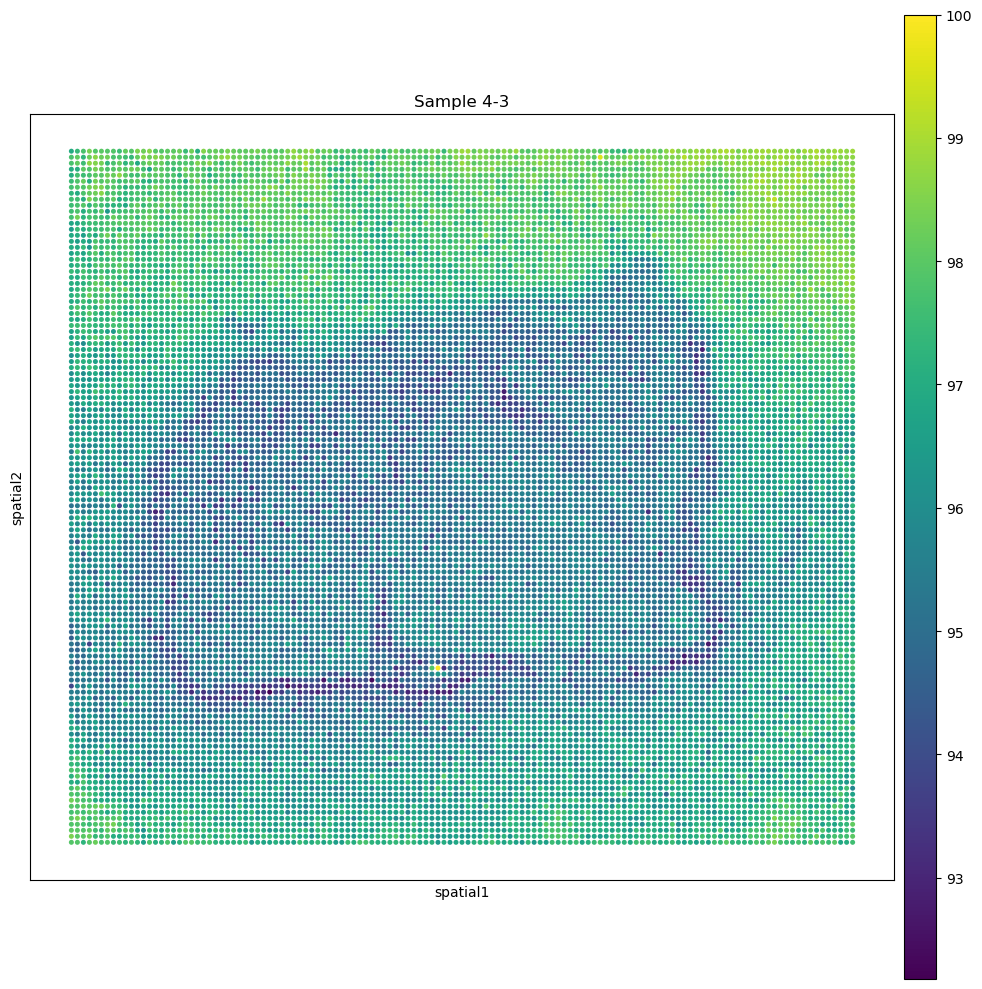

In [72]:
import matplotlib.pyplot as plt
import squidpy as sq

# Assuming 'adata' is an AnnData object
sample_name = ["4-3"]
data_name = [adata]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust size as needed

# Add 'pct_counts_in_top_500_genes' to obs for the given sample
mask = adata.obs['sample'] == sample_name[0]
data_name[0].obs.loc[mask, 'pct_counts_in_top_500_genes'] = adata.obs.loc[mask, 'pct_counts_in_top_500_genes']

# Plot spatial scatter
sq.pl.spatial_scatter(data_name[0], alpha=1.0, img=False, img_alpha=1.0, img_cmap=None, 
                      color=["pct_counts_in_top_500_genes"], ax=ax)

# Set title
ax.set_title(f'Sample {sample_name[0]}')

# Adjust layout and save
plt.tight_layout()
plt.savefig("pct_counts_in_top_500_genes_scatter_per_sample.png", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
#adata = adata[:, ~adata.var.index.isin(top_mzs)].copy()


In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)
adata

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", 'pct_counts_in_top_500_genes'],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
sample_name = ["1-1", "1-2", "1-3", "1-4", "1-5", "1-6", 
              "2-1", "2-2", "2-3", "2-4", "2-5", "2-6", "2-7",
              "3-1", "3-2", "3-3", "3-4", "3-5",
              "4-1", "4-2", "4-3", "4-4", "4-5", "4-6"]

data_name = [adata_yc1, adata_yc2, adata_yc3, adata_yc4, adata_yc5, adata_yc6,
                   adata_ac1, adata_ac2, adata_ac3, adata_ac4, adata_ac5, adata_ac6, adata_ac7,
                   adata_yad1, adata_yad2, adata_yad3, adata_yad4, adata_yad5,
                   adata_aad1, adata_aad2, adata_aad3, adata_aad4, adata_aad5, adata_aad6]
import matplotlib.pyplot as plt
import squidpy as sq
# Assuming data_name is a list of your AnnData objects for the 8 samples
# Create a figure with 2 rows and 4 columns (8 plots total)
fig, axs = plt.subplots(6, 4, figsize=(20, 10))  # Adjust figsize as needed

# Loop through each sample
for x in range(24):
    # Add pct_counts_mt to the obs of each AnnData object
    data_name[x].obs['pct_counts_in_top_500_genes'] = adata.obs['pct_counts_in_top_500_genes'][adata.obs['sample'] == sample_name[x]]
    
    # Plot spatial scatter for each sample in the corresponding subplot
    ax = axs[x // 4, x % 4]  # Determine the appropriate subplot
    sq.pl.spatial_scatter(data_name[x], alpha=1.0, img=False, img_alpha=1.0, img_cmap=None, color=["pct_counts_in_top_500_genes"], ax=ax)
    ax.set_title(f'Sample {sample_name[x]}')  # Set title for each subplot

# Adjust layout
plt.tight_layout()
plt.savefig("pct_counts_in_top_500_genes scatter per sample", dpi=600, bbox_inches='tight') 
plt.show()

In [ ]:
sc.pp.normalize_total(adata)
adata

In [ ]:
sc.pp.log1p(adata)
adata

In [ ]:
sc.tl.pca(adata)

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10,  use_rep="X_pca")
adata

In [ ]:
sc.tl.umap(adata)
adata

In [ ]:
sc.tl.leiden(
    adata, key_added="leiden", flavor="igraph", directed=False, n_iterations=2
)
adata

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=300)  # You can adjust `n_top_genes`
adata

In [ ]:
sc.tl.tsne(adata)

In [ ]:
import matplotlib.pyplot as plt

# Set the figure size using Matplotlib
plt.figure(figsize=(20, 16))

# Plot t-SNE with larger points
sc.pl.tsne(adata, color=['leiden'], size=0.4)

# Show the plot
plt.show()


In [ ]:
sc.pl.umap(adata, color=['leiden'])  # Or 'clusters' if you have clusters
adata

In [ ]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=0.4,
)

In [ ]:
sc.pl.tsne(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=0.4,
)

In [ ]:
sc.pl.tsne(
    adata,
    color='batch',
    # Setting a smaller point size to get prevent overlap
    size=0.4,
)

In [ ]:
sc.pl.umap(
    adata,
    color='batch',
    # Setting a smaller point size to get prevent overlap
    size=0.4,
)

In [ ]:
sc.pl.embedding(adata, basis="spatial", color="leiden")


In [ ]:
sc.pl.embedding(adata, basis="spatial", color="batch")


In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)


In [ ]:
sc.pl.pca(
    adata,
    color=["age_group", "age_group", "disease_status", "disease_status"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    wspace=0.5,
    ncols=2,
    size=3,
)

In [ ]:
sc.pl.pca(
    adata,
    color=["batch", "batch", "pct_counts_in_top_500_genes", "pct_counts_in_top_500_genes"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    wspace=0.5,
    ncols=2,
    size=3,
)

In [ ]:
sc.pl.pca(
    adata,
    color=["total_counts", "total_counts", "pct_counts_in_top_500_genes", "pct_counts_in_top_500_genes"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    wspace=0.5,
    ncols=2,
    size=3,
)

In [ ]:
sc.tl.rank_genes_groups(adata,"leiden", method="t-test")


In [ ]:
sc.pl.rank_genes_groups_heatmap(adata, groups="9", n_genes=10, groupby="leiden")